# 07 — Final Analysis: Residuals, Volatility, Feature Importance, Cross-Region
**Environment:** Google Colab (GPU recommended for Section 3)

This notebook fills the four deeper-analysis gaps flagged for the final report:

1. **Residual & error diagnostics per model** — beyond aggregate RMSE/MAE, look at *when* models fail, residual distributions, autocorrelation, and heteroscedasticity.
2. **Stable vs. volatile deep dive** — per-model × per-event breakdown, family aggregation, per-event prediction overlays.
3. **Feature importance across model families** — unified *permutation importance* (Δ-RMSE) comparable across Linear / Ridge / Lasso / Random Forest / XGBoost / MLP / LSTM / GRU.
4. **Cross-region generalization** — national-trained vs. region-trained comparison turned into a structured discussion.

The notebook is self-contained: upload at top, run top-to-bottom, download a single zip with all figures + JSON summaries.

---


## Setup — Uploads

Four uploads (in order). Each triggers a separate file picker; select the files listed for that step.

- **UPLOAD 1/4**: `results.zip` — zip of the contents of the local `results/` folder (all existing model JSONs with test predictions + dates). Used by Sections 1, 2.
- **UPLOAD 2/4**: `PET_PRI_GND_DCUS_NUS_W.csv` — original national CSV from `data/raw/`. Used by Sections 1, 2, 3.
- **UPLOAD 3/4**: Five regional XLS files from `data/raw/regional/` (hold Cmd / Ctrl to multi-select). Used by Section 4.
- **UPLOAD 4/4**: `national_allgrades_updated.xls` from `data/raw/national_updated/`. Used by Section 4.


In [1]:
from google.colab import files
import os, zipfile

# UPLOAD 1/4 — results.zip (existing model predictions)
print('=' * 60)
print('UPLOAD 1/4: Select results.zip')
print('  (zip the local results/ folder — all 20 core JSONs)')
print('=' * 60)
up1 = files.upload()
zip_name = [k for k in up1.keys() if k.endswith('.zip')][0]
os.makedirs('results', exist_ok=True)
with zipfile.ZipFile(zip_name, 'r') as zf:
    zf.extractall('results')
# Flatten if zip was created from a parent dir
for root, _, fs in os.walk('results'):
    for f in fs:
        if f.endswith('.json') and root != 'results':
            os.rename(os.path.join(root, f), os.path.join('results', f))
json_files = sorted([f for f in os.listdir('results') if f.endswith('.json')])
print(f'\nUnzipped {len(json_files)} JSON files into results/')


UPLOAD 1/4: Select results.zip
  (zip the local results/ folder — all 20 core JSONs)


Saving results.zip to results.zip

Unzipped 56 JSON files into results/


In [2]:
# UPLOAD 2/4 — PET_PRI_GND_DCUS_NUS_W.csv
print('=' * 60)
print('UPLOAD 2/4: Select PET_PRI_GND_DCUS_NUS_W.csv')
print('  (from data/raw/)')
print('=' * 60)
up2 = files.upload()
print(f'Got: {list(up2.keys())}')


UPLOAD 2/4: Select PET_PRI_GND_DCUS_NUS_W.csv
  (from data/raw/)


Saving PET_PRI_GND_DCUS_NUS_W.csv to PET_PRI_GND_DCUS_NUS_W.csv
Got: ['PET_PRI_GND_DCUS_NUS_W.csv']


In [3]:
# UPLOAD 3/4 — Five regional XLS files (multi-select)
print('=' * 60)
print('UPLOAD 3/4: Select ALL 5 regional XLS files at once')
print('  (from data/raw/regional/ — hold Cmd/Ctrl to multi-select)')
print('    padd1_east_coast.xls')
print('    padd2_midwest.xls')
print('    padd3_gulf_coast.xls')
print('    padd4_rocky_mountain.xls')
print('    padd5_west_coast.xls')
print('=' * 60)
up3 = files.upload()
print(f'Got: {sorted(up3.keys())}')


UPLOAD 3/4: Select ALL 5 regional XLS files at once
  (from data/raw/regional/ — hold Cmd/Ctrl to multi-select)
    padd1_east_coast.xls
    padd2_midwest.xls
    padd3_gulf_coast.xls
    padd4_rocky_mountain.xls
    padd5_west_coast.xls


Saving padd1_east_coast.xls to padd1_east_coast.xls
Saving padd2_midwest.xls to padd2_midwest.xls
Saving padd3_gulf_coast.xls to padd3_gulf_coast.xls
Saving padd4_rocky_mountain.xls to padd4_rocky_mountain.xls
Saving padd5_west_coast.xls to padd5_west_coast.xls
Got: ['padd1_east_coast.xls', 'padd2_midwest.xls', 'padd3_gulf_coast.xls', 'padd4_rocky_mountain.xls', 'padd5_west_coast.xls']


In [4]:
# UPLOAD 4/4 — national_allgrades_updated.xls
print('=' * 60)
print('UPLOAD 4/4: Select national_allgrades_updated.xls')
print('  (from data/raw/national_updated/)')
print('=' * 60)
up4 = files.upload()
print(f'Got: {list(up4.keys())}')


UPLOAD 4/4: Select national_allgrades_updated.xls
  (from data/raw/national_updated/)


Saving national_allgrades_updated.xls to national_allgrades_updated.xls
Saving national_regular_updated.xls to national_regular_updated.xls
Got: ['national_allgrades_updated.xls', 'national_regular_updated.xls']


## Imports, Environment, and Utility Functions

Self-contained versions of `src/data_utils.py` and `src/evaluate.py` so the notebook runs standalone on Colab.


In [5]:
!pip install -q statsmodels xgboost xlrd==1.2.0 2>&1 | tail -n 2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 10.3 MB/s eta 0:00:00


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, os, copy, warnings, glob
from collections import defaultdict
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import xlrd
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf
from scipy import stats as sp_stats

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

os.makedirs('outputs', exist_ok=True)
for sub in ['sec1', 'sec2', 'sec3', 'sec4']:
    os.makedirs(f'outputs/{sub}', exist_ok=True)

print(f'torch {torch.__version__} | device: {device}')


torch 2.10.0+cu128 | device: cuda


In [7]:
# -------- Data pipeline (from src/data_utils.py) --------
TARGET_COL = 'A1'

def load_raw_data(fname='PET_PRI_GND_DCUS_NUS_W.csv'):
    df = pd.read_csv(fname)
    df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
    return df.sort_values('Date').reset_index(drop=True)

def clean_data(df):
    price_cols = [c for c in df.columns if c != 'Date']
    for c in price_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df[price_cols] = df[price_cols].ffill().bfill()
    return df

def add_features(df, target_col=TARGET_COL,
                 lags=(1, 2, 3, 4, 8, 12),
                 rolling_windows=(4, 8, 12)):
    df = df.copy()
    for lag in lags:
        df[f'{target_col}_lag{lag}'] = df[target_col].shift(lag)
    for w in rolling_windows:
        df[f'{target_col}_rolling_mean_{w}'] = df[target_col].shift(1).rolling(w).mean()
        df[f'{target_col}_rolling_std_{w}'] = df[target_col].shift(1).rolling(w).std()
    df[f'{target_col}_diff_1'] = df[target_col].diff(1)
    df[f'{target_col}_diff_4'] = df[target_col].diff(4)
    df[f'{target_col}_pct_change_1'] = df[target_col].pct_change(1)
    df[f'{target_col}_pct_change_4'] = df[target_col].pct_change(4)
    df['month'] = df['Date'].dt.month
    df['quarter'] = df['Date'].dt.quarter
    df['year'] = df['Date'].dt.year
    df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    for col in ['R1', 'M1', 'P1', 'D1']:
        if col in df.columns and col != target_col:
            df[f'{col}_lag1'] = df[col].shift(1)
    return df

def create_target(df, target_col=TARGET_COL, horizon=1):
    df = df.copy()
    df['target'] = df[target_col].shift(-horizon)
    return df

def get_feature_columns(df, mode='full'):
    exclude = {'Date', 'target', TARGET_COL,
               'A1', 'A2', 'A3', 'R1', 'R2', 'R3',
               'M1', 'M2', 'M3', 'P1', 'P2', 'P3', 'D1'}
    if mode == 'basic':
        return [c for c in df.columns if c.startswith(f'{TARGET_COL}_lag')]
    return [c for c in df.columns if c not in exclude]

def train_val_test_split(df, train_ratio=0.70, val_ratio=0.15):
    n = len(df)
    a = int(n * train_ratio)
    b = int(n * (train_ratio + val_ratio))
    return df.iloc[:a].copy(), df.iloc[a:b].copy(), df.iloc[b:].copy()

def prepare_data(horizon=1, feature_mode='full', csv='PET_PRI_GND_DCUS_NUS_W.csv'):
    df = load_raw_data(csv)
    df = clean_data(df)
    df = add_features(df)
    df = create_target(df, horizon=horizon)
    df = df.dropna().reset_index(drop=True)
    fc = get_feature_columns(df, mode=feature_mode)
    tr, va, te = train_val_test_split(df)
    return {'train': tr, 'val': va, 'test': te, 'feature_cols': fc, 'full_df': df}

def rmse(y, yhat): return float(np.sqrt(np.mean((np.asarray(y) - np.asarray(yhat)) ** 2)))
def mae(y, yhat):  return float(np.mean(np.abs(np.asarray(y) - np.asarray(yhat))))
def mape(y, yhat):
    y, yhat = np.asarray(y), np.asarray(yhat)
    m = y != 0
    return float(np.mean(np.abs((y[m] - yhat[m]) / y[m])) * 100)

# XLS loader (matches 06/06b)
def load_xls_price_series(fname):
    wb = xlrd.open_workbook(fname)
    ws = wb.sheet_by_name('Data 1')
    dates, prices = [], []
    for i in range(3, ws.nrows):
        dates.append(xlrd.xldate_as_datetime(ws.cell_value(i, 0), wb.datemode))
        prices.append(ws.cell_value(i, 1))
    out = pd.DataFrame({'Date': pd.to_datetime(dates), 'Price': prices})
    return out.sort_values('Date').reset_index(drop=True)

print('Utilities defined.')


Utilities defined.


## Load Core Data & Saved Model Predictions

Rebuilds the h=1 chronological split used by all the earlier notebooks, then loads every saved JSON and aligns each model's test predictions to the shared test-set dates. Sections 1 and 2 operate on this aligned store.


In [8]:
data = prepare_data(horizon=1, feature_mode='full')
test_df     = data['test'].reset_index(drop=True)
test_dates  = pd.to_datetime(test_df['Date']).values
test_actual = test_df['target'].values
print(f'Test window: {pd.to_datetime(test_dates[0]).date()} → '
      f'{pd.to_datetime(test_dates[-1]).date()}   ({len(test_actual)} weeks)')

# Load all result JSONs with test predictions + dates
def load_preds(folder='results'):
    store = {}
    for f in sorted(os.listdir(folder)):
        if not f.endswith('.json'): continue
        try:
            d = json.load(open(os.path.join(folder, f)))
        except Exception:
            continue
        if 'predictions' not in d or 'test' not in d.get('predictions', {}):
            continue
        key = (d['model_name'], d['horizon'], d.get('feature_mode', 'full'))
        store[key] = {
            'preds': np.array(d['predictions']['test']),
            'dates': pd.to_datetime(d['dates']['test']),
            'metrics': d.get('metrics', {}),
        }
    return store

pred_store = load_preds('results')
print(f'\nLoaded predictions for {len(pred_store)} (model, horizon, features) combos:')
for (m, h, fm) in sorted(pred_store.keys(), key=lambda x: (x[1], x[0])):
    n = len(pred_store[(m, h, fm)]['preds'])
    print(f'  h={h}  {fm:6s}  n={n:4d}   {m}')


Test window: 2017-03-06 → 2021-01-18   (203 weeks)

Loaded predictions for 20 (model, horizon, features) combos:
  h=1  full    n= 203   GRU (h=64,L=2,s=12)
  h=1  full    n= 203   LSTM-A (h=32,L=1,s=8)
  h=1  full    n= 203   LSTM-B (h=64,L=1,s=12)
  h=1  full    n= 203   LSTM-C (h=64,L=2,s=12)
  h=1  full    n= 203   LSTM-D (h=128,L=2,s=12)
  h=1  full    n= 203   Lasso Regression
  h=1  basic   n= 203   Linear Regression
  h=1  full    n= 203   Linear Regression
  h=1  full    n= 203   MLP-Large
  h=1  full    n= 203   MLP-Medium
  h=1  full    n= 203   MLP-Small
  h=1  full    n= 203   Naive Baseline
  h=1  full    n= 203   Random Forest
  h=1  full    n= 203   Ridge Regression
  h=1  full    n= 203   XGBoost
  h=4  full    n= 202   LSTM-B (h=64,L=1,s=12)
  h=4  full    n= 202   MLP-Large
  h=4  full    n= 202   Random Forest
  h=4  full    n= 202   Ridge Regression
  h=4  full    n= 202   XGBoost


In [9]:
# Build aligned-to-test-set arrays for all h=1, full-feature models
def align_to_test(entry, test_dates):
    pred_dates = pd.to_datetime(entry['dates'])
    preds = entry['preds']
    # Build dict of date -> pred
    pd_map = dict(zip(pred_dates, preds))
    aligned = np.array([pd_map.get(pd.Timestamp(d), np.nan) for d in test_dates])
    return aligned

aligned = {}
for (m, h, fm), entry in pred_store.items():
    if h != 1 or fm != 'full': continue
    a = align_to_test(entry, test_dates)
    if np.isnan(a).all(): continue
    aligned[m] = a

print(f'Aligned {len(aligned)} h=1/full models to test window.')
print('Models:', sorted(aligned.keys()))


Aligned 14 h=1/full models to test window.
Models: ['GRU (h=64,L=2,s=12)', 'LSTM-A (h=32,L=1,s=8)', 'LSTM-B (h=64,L=1,s=12)', 'LSTM-C (h=64,L=2,s=12)', 'LSTM-D (h=128,L=2,s=12)', 'Lasso Regression', 'Linear Regression', 'MLP-Large', 'MLP-Medium', 'MLP-Small', 'Naive Baseline', 'Random Forest', 'Ridge Regression', 'XGBoost']


---
# Section 1 — Residual & Error Diagnostics per Model

Overall metrics (RMSE, MAE, MAPE) hide *when* and *how* models fail. This section adds:

- **1.1** Residual statistics — bias, std, skew, kurtosis, Ljung-Box p-value (is there signal left in the residuals?).
- **1.2** Residual time-series with crisis shading — *when* each model fails.
- **1.3** Worst-10-weeks table for the best model — concrete weeks with largest errors, tagged to geopolitical events.
- **1.4** Q-Q plots — normality assumption check.
- **1.5** Residual vs. predicted scatter — heteroscedasticity check.
- **1.6** Autocorrelation (ACF) of residuals — models with lag-1 autocorrelation are leaving forecast signal on the table.


In [10]:
# 1.1 — Residual statistics table
rows = []
for m, yhat in aligned.items():
    res = yhat - test_actual
    # Ljung-Box on first 10 lags
    try:
        lb = acorr_ljungbox(res, lags=[10], return_df=True)
        lb_p = float(lb['lb_pvalue'].iloc[0])
    except Exception:
        lb_p = np.nan
    rows.append({
        'Model': m,
        'RMSE': rmse(test_actual, yhat),
        'Bias (mean)': float(res.mean()),
        'Std': float(res.std(ddof=1)),
        'Skew': float(sp_stats.skew(res)),
        'Kurtosis (excess)': float(sp_stats.kurtosis(res)),
        'Ljung-Box p (lag 10)': lb_p,
    })
res_stats = pd.DataFrame(rows).sort_values('RMSE').reset_index(drop=True)
res_stats.round(4).to_csv('outputs/sec1/residual_stats.csv', index=False)
res_stats.round(4)


,Model,RMSE,Bias (mean),Std,Skew,Kurtosis (excess),Ljung-Box p (lag 10)
0,Linear Regression,0.0412,-0.0003,0.0413,-0.5769,4.5613,0.0000
1,Lasso Regression,0.0543,0.0401,0.0366,-1.9205,14.1485,0.8407
2,Naive Baseline,0.0766,-0.0003,0.0768,-0.1908,2.0849,0.0000
3,XGBoost,0.0772,0.0451,0.0628,-0.5777,3.4375,0.0000
4,"LSTM-B (h=64,L=1,s=12)",0.0921,0.0590,0.0709,-0.8065,4.9232,0.0000
5,"GRU (h=64,L=2,s=12)",0.0933,0.0553,0.0754,-0.7262,4.0864,0.0000
6,"LSTM-A (h=32,L=1,s=8)",0.0999,0.0676,0.0738,-0.4312,3.0051,0.0000
7,"LSTM-C (h=64,L=2,s=12)",0.1003,0.0582,0.0819,0.0067,2.8962,0.0000
8,Random Forest,0.1065,0.0854,0.0638,0.1195,1.7364,0.0000
9,"LSTM-D (h=128,L=2,s=12)",0.1087,0.0771,0.0768,-0.5590,4.1183,0.0000


In [11]:
# Define volatile periods + named events (reused by Section 2)
EVENTS = [
    ('Hurricane Katrina',    '2005-08-29', '2005-10-31'),
    ('2008 Financial Crisis','2008-07-01', '2009-03-31'),
    ('2014-16 Oil Crash',    '2014-06-01', '2016-02-29'),
    ('COVID-19 Pandemic',    '2020-03-01', '2020-06-30'),
    ('Russia-Ukraine Spike', '2022-02-24', '2022-08-31'),
]
VOLATILE_PERIODS = [(pd.Timestamp(s), pd.Timestamp(e), n) for n, s, e in EVENTS]

def event_label(ts):
    ts = pd.Timestamp(ts)
    for s, e, n in VOLATILE_PERIODS:
        if s <= ts <= e: return n
    return '—'

print('Events registered:', [e[0] for e in EVENTS])


Events registered: ['Hurricane Katrina', '2008 Financial Crisis', '2014-16 Oil Crash', 'COVID-19 Pandemic', 'Russia-Ukraine Spike']


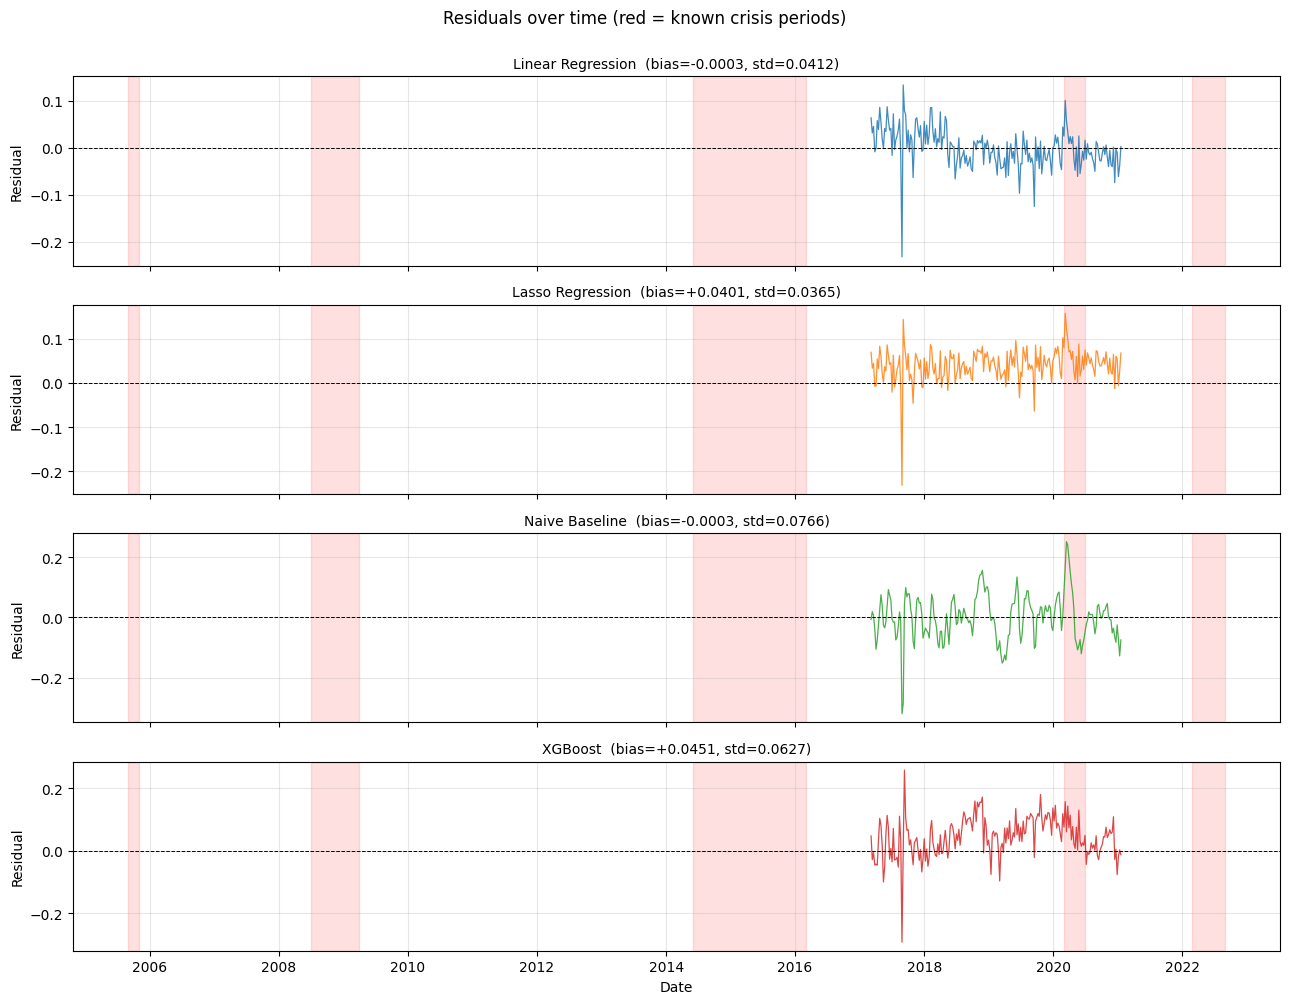

In [12]:
# 1.2 — Residual time-series, top-4 h=1 models with crisis shading
top4 = res_stats.head(4)['Model'].tolist()
fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
test_dates_ts = pd.to_datetime(test_dates)

for ax, m, c in zip(axes, top4, colors):
    res = aligned[m] - test_actual
    ax.plot(test_dates_ts, res, color=c, linewidth=0.9, alpha=0.85)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.7)
    for s, e, n in VOLATILE_PERIODS:
        ax.axvspan(s, e, alpha=0.12, color='red')
    ax.set_title(f'{m}  (bias={res.mean():+.4f}, std={res.std():.4f})', fontsize=10)
    ax.set_ylabel('Residual')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Date')
fig.suptitle('Residuals over time (red = known crisis periods)', fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig('outputs/sec1/residuals_timeseries.png', dpi=120, bbox_inches='tight')
plt.show()


In [13]:
# 1.3 — Worst-10-weeks for the best model
best_model = res_stats.iloc[0]['Model']
best_pred = aligned[best_model]
worst = pd.DataFrame({
    'Date': pd.to_datetime(test_dates),
    'Actual': test_actual,
    f'Pred ({best_model})': best_pred,
    'Abs Error': np.abs(best_pred - test_actual),
}).sort_values('Abs Error', ascending=False).head(10).reset_index(drop=True)
worst['Event'] = worst['Date'].apply(event_label)
worst.round(4).to_csv('outputs/sec1/worst_weeks_best_model.csv', index=False)
print(f'Top 10 worst weeks for {best_model}:')
worst.round(4)


Top 10 worst weeks for Linear Regression:


,Date,Actual,Pred (Linear Regression),Abs Error,Event
0,2017-08-28,2.794,2.5619,0.2321,—
1,2017-09-04,2.800,2.9341,0.1341,—
2,2019-09-16,2.741,2.6163,0.1247,—
3,2020-03-09,2.343,2.4441,0.1011,COVID-19 Pandemic
4,2019-06-24,2.798,2.7014,0.0966,—
5,2017-06-05,2.479,2.5666,0.0876,—
6,2017-04-24,2.522,2.6084,0.0864,—
7,2018-02-12,2.676,2.7621,0.0861,—
8,2018-02-05,2.724,2.8095,0.0855,—
9,2017-09-11,2.750,2.8285,0.0785,—


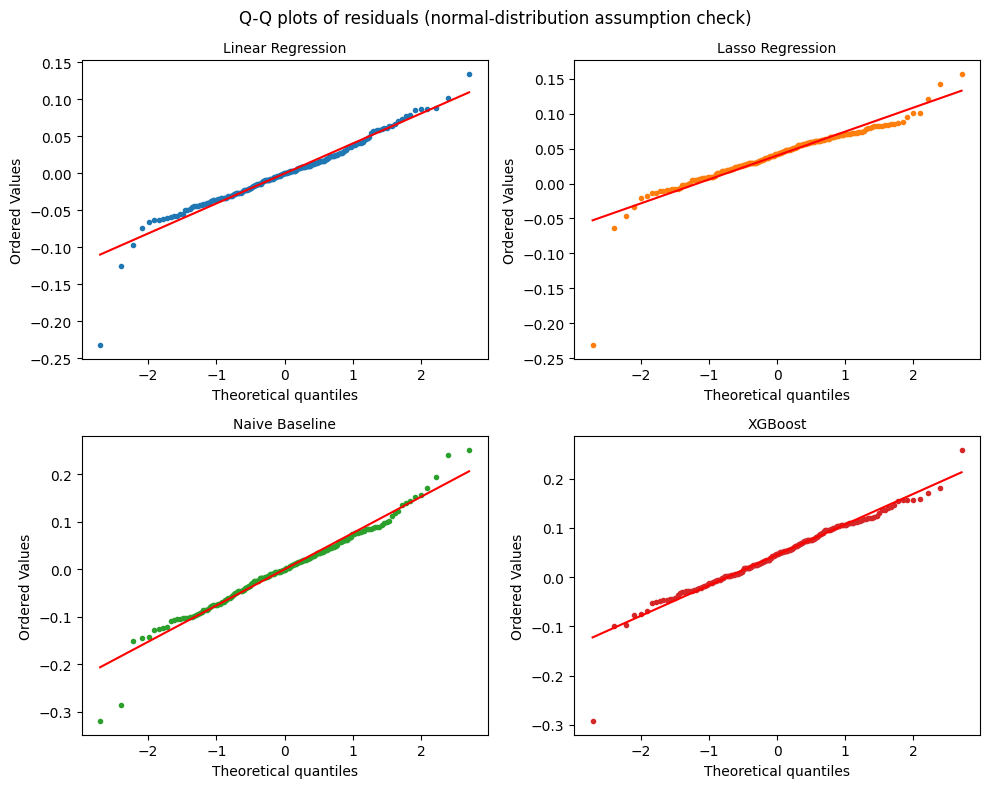

In [14]:
# 1.4 — Q-Q plots (top-4)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, m, c in zip(axes.flat, top4, colors):
    res = aligned[m] - test_actual
    sp_stats.probplot(res, dist='norm', plot=ax)
    ax.set_title(m, fontsize=10)
    ax.get_lines()[0].set_markerfacecolor(c)
    ax.get_lines()[0].set_markeredgecolor(c)
    ax.get_lines()[0].set_markersize(3)
fig.suptitle('Q-Q plots of residuals (normal-distribution assumption check)', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/sec1/qq_plots.png', dpi=120, bbox_inches='tight')
plt.show()


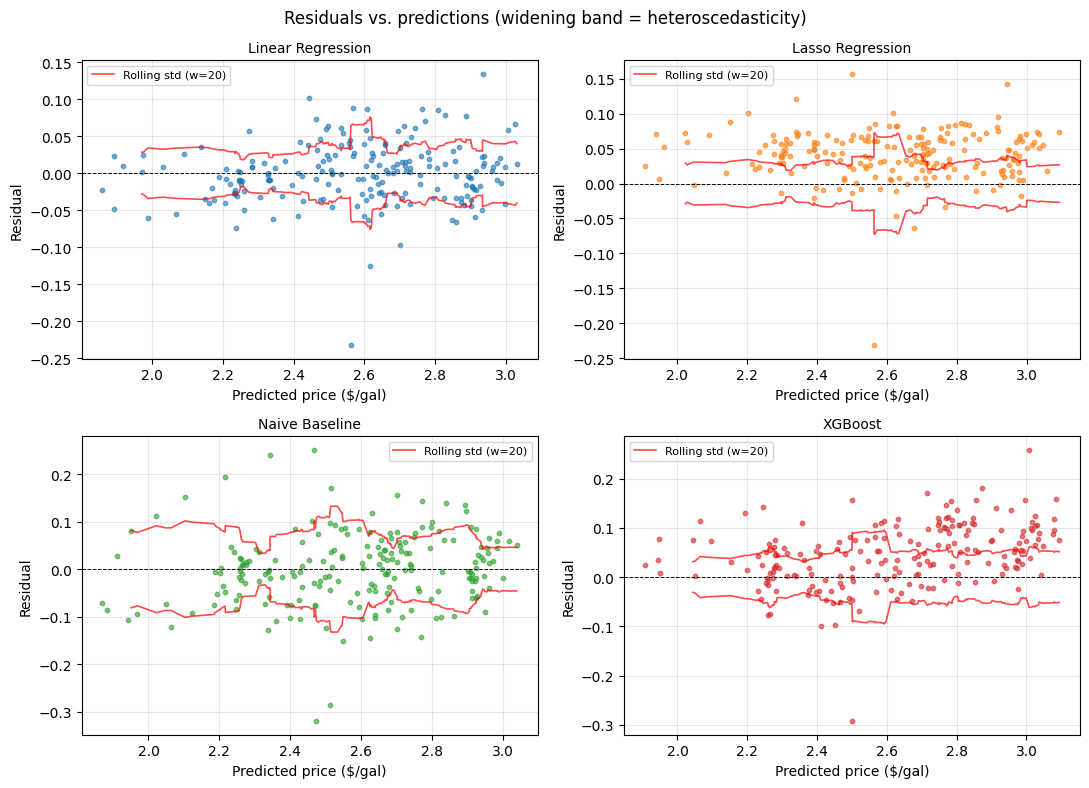

In [15]:
# 1.5 — Residual vs. predicted scatter (heteroscedasticity)
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, m, c in zip(axes.flat, top4, colors):
    yhat = aligned[m]
    res = yhat - test_actual
    ax.scatter(yhat, res, s=10, alpha=0.6, color=c)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.7)
    # Rolling std band
    order = np.argsort(yhat)
    ys = yhat[order]; rs = res[order]
    window = max(20, len(rs) // 15)
    roll_std = pd.Series(rs).rolling(window, min_periods=5).std().values
    ax.plot(ys, roll_std, color='red', linewidth=1.2, alpha=0.7, label=f'Rolling std (w={window})')
    ax.plot(ys, -roll_std, color='red', linewidth=1.2, alpha=0.7)
    ax.set_title(m, fontsize=10)
    ax.set_xlabel('Predicted price ($/gal)')
    ax.set_ylabel('Residual')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
fig.suptitle('Residuals vs. predictions (widening band = heteroscedasticity)', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/sec1/heteroscedasticity.png', dpi=120, bbox_inches='tight')
plt.show()


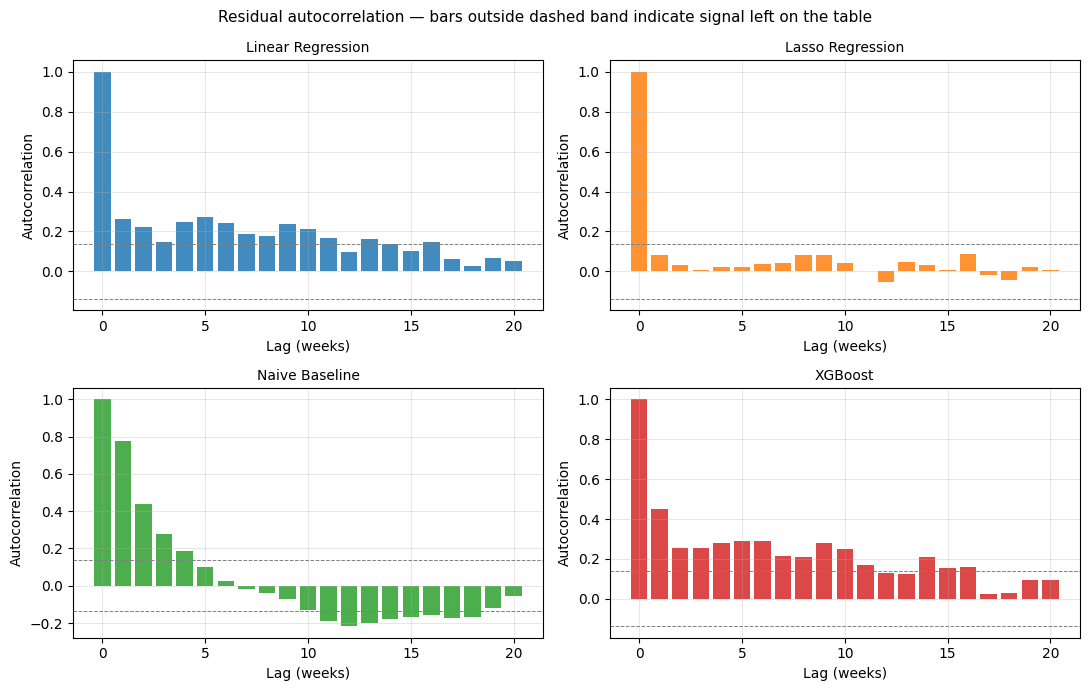

In [16]:
# 1.6 — ACF of residuals, lags 0-20
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, m, c in zip(axes.flat, top4, colors):
    res = aligned[m] - test_actual
    ac = acf(res, nlags=20, fft=True)
    lags = np.arange(len(ac))
    ax.bar(lags, ac, color=c, alpha=0.85)
    # 95% confidence band
    n = len(res)
    band = 1.96 / np.sqrt(n)
    ax.axhline(band, color='gray', linestyle='--', linewidth=0.7)
    ax.axhline(-band, color='gray', linestyle='--', linewidth=0.7)
    ax.set_title(m, fontsize=10)
    ax.set_xlabel('Lag (weeks)')
    ax.set_ylabel('Autocorrelation')
    ax.grid(alpha=0.3)
fig.suptitle('Residual autocorrelation — bars outside dashed band indicate signal left on the table', fontsize=11)
plt.tight_layout()
plt.savefig('outputs/sec1/residual_acf.png', dpi=120, bbox_inches='tight')
plt.show()


In [17]:
# Persist Section 1 summary JSON
sec1_summary = {
    'best_model': best_model,
    'top4_models': top4,
    'residual_stats': res_stats.round(6).to_dict(orient='records'),
    'worst_weeks_best_model': worst.assign(Date=worst['Date'].astype(str)).to_dict(orient='records'),
}
json.dump(sec1_summary, open('outputs/sec1/summary.json', 'w'), indent=2, default=str)
print('Section 1 outputs written to outputs/sec1/')


Section 1 outputs written to outputs/sec1/


---
# Section 2 — Stable vs. Volatile Deep Dive

Previous notebooks showed a high-level stable-vs-volatile RMSE split. This section goes deeper.

**Scope note.** The h=1 chronological test window is **2017-03-06 → 2021-01-18**. Of the 5 named crises in our event catalogue, only **COVID-19** overlaps this test window (~18 weeks). The earlier events (Katrina, 2008, 2014–16) are covered in notebook 06's *retrain-before-event* protocol — we do not duplicate that here. Instead, Section 2 focuses on what the core test window can actually answer:

- **2.1** Per-model × regime RMSE **heatmap** — columns are `Stable`, `High Volatility` (data-driven: top 20 % weeks by 12-week rolling std of price), and any named event with ≥ 5 overlapping test weeks (i.e. COVID).
- **2.2** Family aggregation — classical / tree / neural average RMSE per regime.
- **2.3** Per-event **prediction overlay** — top-3 models vs. actual during COVID (±6 week buffer).
- **2.4** Degradation ratio — `RMSE(volatile) / RMSE(stable)` per model, where volatile = data-driven high-volatility label.


High-volatility threshold (80th pct of 12-week rolling std): $0.1262
High-volatility test weeks: 41 / 203
Named events with >=5 test weeks: ['COVID-19 Pandemic']
Final regime weeks:
  Stable              : 157 weeks
  High Volatility     : 41 weeks
  COVID-19 Pandemic   : 18 weeks


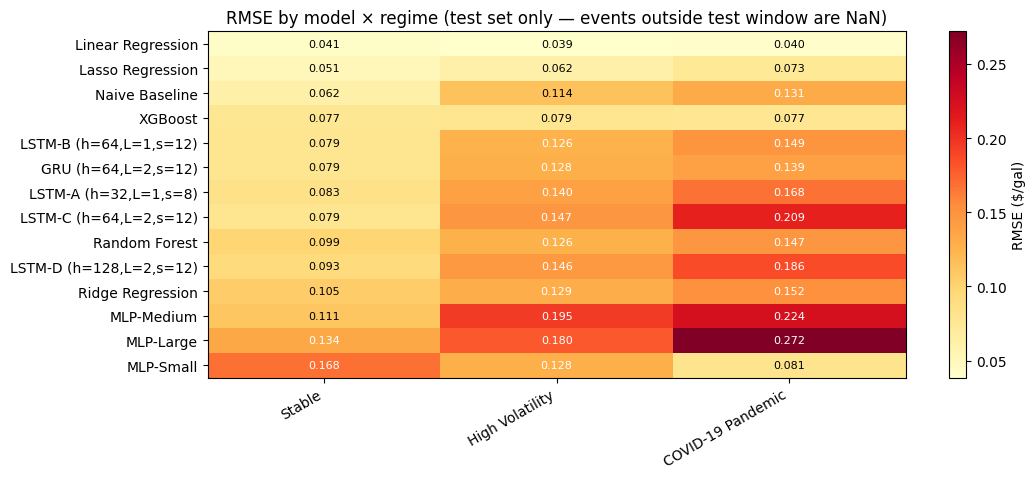

,Stable,High Volatility,COVID-19 Pandemic
Model,,,
Linear Regression,0.0414,0.0386,0.0401
Lasso Regression,0.0509,0.0615,0.0734
Naive Baseline,0.0617,0.1135,0.1309
XGBoost,0.0767,0.0786,0.0774
"LSTM-B (h=64,L=1,s=12)",0.0787,0.1257,0.1487
"GRU (h=64,L=2,s=12)",0.0786,0.1285,0.1389
"LSTM-A (h=32,L=1,s=8)",0.0834,0.1398,0.1680
"LSTM-C (h=64,L=2,s=12)",0.0791,0.1471,0.2094
Random Forest,0.0988,0.1262,0.1475


In [18]:
# 2.1 — Build regime masks: Stable / High-Volatility / named events with enough overlap
test_ts = pd.to_datetime(test_dates)

# Data-driven volatility label: top 20% of weeks by rolling 12-week std of actual price
price_series = pd.Series(test_actual, index=test_ts)
roll_std = price_series.rolling(12, min_periods=4).std().bfill()
vol_thresh = np.nanpercentile(roll_std.values, 80)
high_vol_mask = (roll_std.values >= vol_thresh)
print(f'High-volatility threshold (80th pct of 12-week rolling std): ${vol_thresh:.4f}')
print(f'High-volatility test weeks: {int(high_vol_mask.sum())} / {len(test_ts)}')

# Named events that overlap the test window with >=5 weeks
MIN_EVENT_WEEKS = 5
regime_masks = {}
event_masks = {}
for name, s, e in EVENTS:
    m_event = (test_ts >= pd.Timestamp(s)) & (test_ts <= pd.Timestamp(e))
    event_masks[name] = m_event
    if m_event.sum() >= MIN_EVENT_WEEKS:
        regime_masks[name] = m_event

print(f'Named events with >={MIN_EVENT_WEEKS} test weeks: {list(regime_masks.keys())}')
union_event = np.zeros(len(test_ts), dtype=bool)
for m in event_masks.values():
    union_event |= m

regime_masks = {
    'Stable':          ~(high_vol_mask | union_event),
    'High Volatility': high_vol_mask,
    **regime_masks,
}
print('Final regime weeks:')
for k, v in regime_masks.items():
    print(f'  {k:20s}: {int(v.sum())} weeks')

rows = []
for m, yhat in aligned.items():
    row = {'Model': m}
    for regime, mask in regime_masks.items():
        row[regime] = rmse(test_actual[mask], yhat[mask]) if mask.sum() else np.nan
    rows.append(row)

regime_df = pd.DataFrame(rows).set_index('Model')
regime_df = regime_df.loc[res_stats['Model'].tolist()]  # order by overall RMSE
regime_df.round(4).to_csv('outputs/sec2/model_regime_rmse.csv')

fig, ax = plt.subplots(figsize=(11, max(4, 0.35 * len(regime_df))))
im = ax.imshow(regime_df.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(regime_df.columns)))
ax.set_xticklabels(regime_df.columns, rotation=30, ha='right')
ax.set_yticks(range(len(regime_df.index)))
ax.set_yticklabels(regime_df.index)
for i in range(regime_df.shape[0]):
    for j in range(regime_df.shape[1]):
        v = regime_df.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                    color='white' if v > regime_df.values[~np.isnan(regime_df.values)].mean() else 'black',
                    fontsize=8)
plt.colorbar(im, ax=ax, label='RMSE ($/gal)')
ax.set_title('RMSE by model × regime (test set only — events outside test window are NaN)')
plt.tight_layout()
plt.savefig('outputs/sec2/heatmap_model_event.png', dpi=120, bbox_inches='tight')
plt.show()
regime_df.round(4)


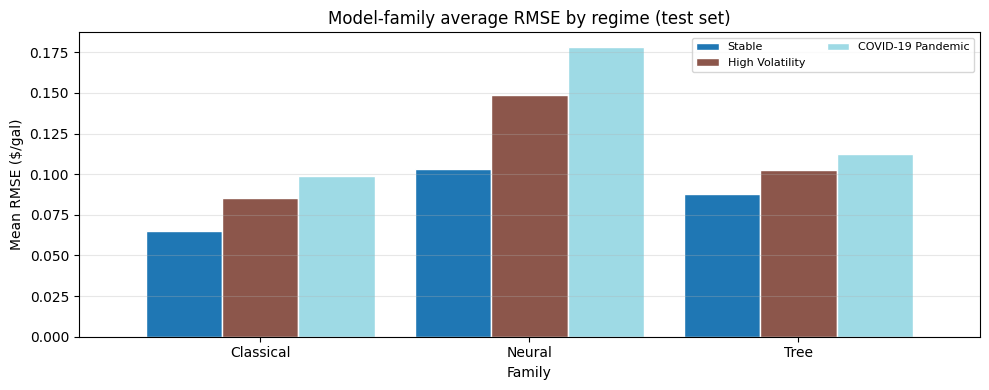

,Stable,High Volatility,COVID-19 Pandemic
Family,,,
Classical,0.0648,0.0856,0.0992
Neural,0.1032,0.1487,0.1784
Tree,0.0878,0.1024,0.1124


In [19]:
# 2.2 — Family aggregation
FAMILY = {
    'Naive Baseline':    'Classical',
    'Linear Regression': 'Classical',
    'Ridge Regression':  'Classical',
    'Lasso Regression':  'Classical',
    'Random Forest':     'Tree',
    'XGBoost':           'Tree',
    'MLP-Small':         'Neural',
    'MLP-Medium':        'Neural',
    'MLP-Large':         'Neural',
    'LSTM-A (h=32,L=1,s=8)':   'Neural',
    'LSTM-B (h=64,L=1,s=12)':  'Neural',
    'LSTM-C (h=64,L=2,s=12)':  'Neural',
    'LSTM-D (h=128,L=2,s=12)': 'Neural',
    'GRU (h=64,L=2,s=12)':     'Neural',
}
fam_df = regime_df.copy()
fam_df['Family'] = fam_df.index.map(FAMILY).fillna('Other')
family_agg = fam_df.groupby('Family').mean(numeric_only=True).round(4)
family_agg.to_csv('outputs/sec2/family_regime_rmse.csv')

fig, ax = plt.subplots(figsize=(10, 4))
family_agg.plot.bar(ax=ax, colormap='tab20', edgecolor='white', width=0.85)
ax.set_ylabel('Mean RMSE ($/gal)')
ax.set_title('Model-family average RMSE by regime (test set)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(alpha=0.3, axis='y')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('outputs/sec2/family_regime_bar.png', dpi=120, bbox_inches='tight')
plt.show()
family_agg


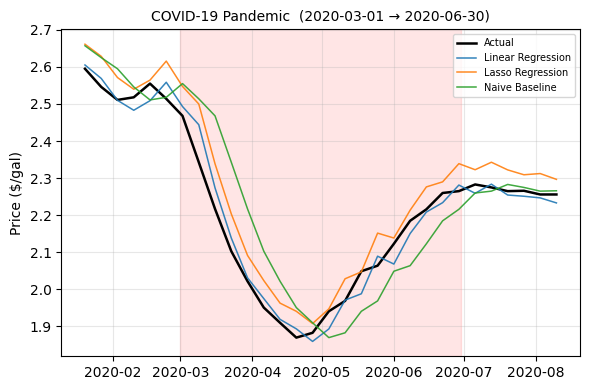

In [20]:
# 2.3 — Per-event prediction overlays (top-3 models)
top3 = res_stats.head(3)['Model'].tolist()
plotable_events = [(n, s, e) for (n, s, e) in EVENTS
                   if ((test_ts >= pd.Timestamp(s)) & (test_ts <= pd.Timestamp(e))).sum() >= 2]

if len(plotable_events) == 0:
    print('No event windows overlap the test split — skipping overlays.')
else:
    rows = min(2, len(plotable_events))
    cols = int(np.ceil(len(plotable_events) / rows))
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows), squeeze=False)
    axes = axes.flatten()
    for i, (name, s, e) in enumerate(plotable_events):
        ax = axes[i]
        mask = (test_ts >= pd.Timestamp(s) - pd.Timedelta(weeks=6)) & \
               (test_ts <= pd.Timestamp(e)   + pd.Timedelta(weeks=6))
        d = test_ts[mask]
        ax.plot(d, test_actual[mask], color='black', linewidth=1.8, label='Actual')
        for m, c in zip(top3, colors):
            ax.plot(d, aligned[m][mask], color=c, linewidth=1.1, alpha=0.9, label=m)
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), color='red', alpha=0.1)
        ax.set_title(f'{name}  ({s} → {e})', fontsize=10)
        ax.set_ylabel('Price ($/gal)')
        ax.grid(alpha=0.3)
        ax.legend(fontsize=7, loc='best')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.savefig('outputs/sec2/event_overlays.png', dpi=120, bbox_inches='tight')
    plt.show()


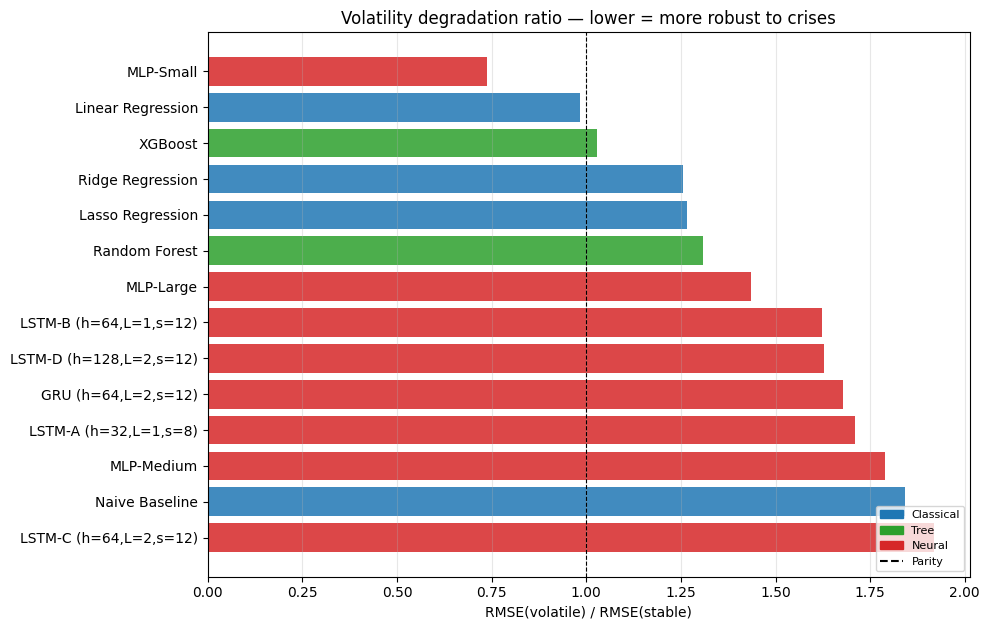

,Model,RMSE (stable),RMSE (volatile),Degradation (vol/stable),Family
0,MLP-Small,0.1682,0.1239,0.7366,Neural
1,Linear Regression,0.0414,0.0407,0.9825,Classical
2,XGBoost,0.0767,0.0788,1.0274,Tree
3,Ridge Regression,0.1052,0.1322,1.2564,Classical
4,Lasso Regression,0.0509,0.0644,1.2650,Classical
5,Random Forest,0.0988,0.1294,1.3093,Tree
6,MLP-Large,0.1339,0.1922,1.4352,Neural
7,"LSTM-B (h=64,L=1,s=12)",0.0787,0.1277,1.6230,Neural
8,"LSTM-D (h=128,L=2,s=12)",0.0927,0.1510,1.6281,Neural
9,"GRU (h=64,L=2,s=12)",0.0786,0.1318,1.6779,Neural


In [21]:
# 2.4 — Degradation ratio = RMSE(high-vol or event) / RMSE(stable)
vol_mask    = regime_masks['High Volatility'] | union_event
stable_mask = regime_masks['Stable']

deg = []
for m, yhat in aligned.items():
    rs = rmse(test_actual[stable_mask], yhat[stable_mask]) if stable_mask.sum() else np.nan
    rv = rmse(test_actual[vol_mask],    yhat[vol_mask])    if vol_mask.sum()    else np.nan
    deg.append({
        'Model': m, 'RMSE (stable)': rs, 'RMSE (volatile)': rv,
        'Degradation (vol/stable)': rv / rs if rs else np.nan,
        'Family': FAMILY.get(m, 'Other'),
    })
deg_df = pd.DataFrame(deg).sort_values('Degradation (vol/stable)').reset_index(drop=True)
deg_df.round(4).to_csv('outputs/sec2/degradation_ratio.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 0.35 * len(deg_df) + 1.5))
fam_color = {'Classical': 'tab:blue', 'Tree': 'tab:green', 'Neural': 'tab:red', 'Other': 'gray'}
bar_colors = [fam_color.get(f, 'gray') for f in deg_df['Family']]
ax.barh(deg_df['Model'], deg_df['Degradation (vol/stable)'], color=bar_colors, alpha=0.85)
ax.invert_yaxis()
ax.axvline(1.0, color='black', linestyle='--', linewidth=0.8, label='Parity')
ax.set_xlabel('RMSE(volatile) / RMSE(stable)')
ax.set_title('Volatility degradation ratio — lower = more robust to crises')
ax.grid(alpha=0.3, axis='x')
# Family legend
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=c, label=f) for f, c in fam_color.items() if f != 'Other']
handles.append(plt.Line2D([0], [0], color='black', linestyle='--', label='Parity'))
ax.legend(handles=handles, loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('outputs/sec2/degradation_bar.png', dpi=120, bbox_inches='tight')
plt.show()
deg_df.round(4)


In [22]:
# Persist Section 2 summary JSON
sec2_summary = {
    'model_event_rmse': regime_df.round(6).to_dict(),
    'family_regime_rmse': family_agg.round(6).to_dict(),
    'degradation': deg_df.round(6).to_dict(orient='records'),
}
json.dump(sec2_summary, open('outputs/sec2/summary.json', 'w'), indent=2, default=str)
print('Section 2 outputs written to outputs/sec2/')


Section 2 outputs written to outputs/sec2/


---
# Section 3 — Feature Importance Across Families (Permutation Importance)

No prior notebook did a systematic cross-family importance study. We use **permutation importance**: for each feature, shuffle that column in the validation set, re-predict, measure the **ΔRMSE**. Same units across *every* model family — the only metric that lets us put Linear coefficients, XGBoost splits, and LSTM sequence sensitivity on one axis.

- Retrain best variant per family: LR / Ridge / Lasso / Random Forest / XGBoost / MLP / LSTM / GRU.
- Compute permutation importance on the **validation** set (not test — we keep test untouched for Sections 1, 2).
- Heatmap (top-15 features × 8 models), feature-category aggregation, and top-shared-features analysis.


In [23]:
# 3.1 — Retrain tabular models (classical + tree + MLP)
Xtr, Xva, Xte = data['train'], data['val'], data['test']
FC = data['feature_cols']
X_train = Xtr[FC].values
y_train = Xtr['target'].values
X_val   = Xva[FC].values
y_val   = Xva['target'].values
X_test  = Xte[FC].values
y_test  = Xte['target'].values

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)

tabular_models = {}
print('Training classical + tree models...')
for name, m in [
    ('Linear Regression', LinearRegression()),
    ('Ridge Regression',  Ridge(alpha=1.0, random_state=SEED)),
    ('Lasso Regression',  Lasso(alpha=0.001, max_iter=20000, random_state=SEED)),
]:
    m.fit(X_train_s, y_train)
    tabular_models[name] = ('scaled', m)
    print(f'  {name:20s} val RMSE = {rmse(y_val, m.predict(X_val_s)):.4f}')

rf = RandomForestRegressor(n_estimators=500, max_depth=12, min_samples_split=5,
                           random_state=SEED, n_jobs=-1).fit(X_train, y_train)
tabular_models['Random Forest'] = ('raw', rf)
print(f'  Random Forest        val RMSE = {rmse(y_val, rf.predict(X_val)):.4f}')

xgbm = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                        subsample=0.9, colsample_bytree=0.9,
                        random_state=SEED, n_jobs=-1, verbosity=0)
xgbm.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
tabular_models['XGBoost'] = ('raw', xgbm)
print(f'  XGBoost              val RMSE = {rmse(y_val, xgbm.predict(X_val)):.4f}')


Training classical + tree models...
  Linear Regression    val RMSE = 0.0446
  Ridge Regression     val RMSE = 0.0567
  Lasso Regression     val RMSE = 0.0447
  Random Forest        val RMSE = 0.0790
  XGBoost              val RMSE = 0.0581


In [24]:
# 3.2 — MLP training (PyTorch)
class MLP(nn.Module):
    def __init__(self, in_dim, hidden=(128, 64, 32), dropout=0.2):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x).squeeze(-1)

def train_mlp(X_tr, y_tr, X_va, y_va, epochs=250, lr=1e-3, patience=25, bs=32):
    model = MLP(X_tr.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=8)
    loss_fn = nn.MSELoss()
    ds = TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr))
    dl = DataLoader(ds, batch_size=bs, shuffle=False)
    best_state, best_val, patience_ctr = None, float('inf'), 0
    Xv_t = torch.FloatTensor(X_va).to(device)
    yv_t = torch.FloatTensor(y_va).to(device)
    for ep in range(epochs):
        model.train()
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        model.eval()
        with torch.no_grad():
            vloss = float(loss_fn(model(Xv_t), yv_t).item())
        sch.step(vloss)
        if vloss < best_val:
            best_val, best_state, patience_ctr = vloss, copy.deepcopy(model.state_dict()), 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience: break
    model.load_state_dict(best_state)
    return model

print('Training MLP...')
mlp = train_mlp(X_train_s, y_train, X_val_s, y_val)
mlp.eval()
with torch.no_grad():
    mlp_val = mlp(torch.FloatTensor(X_val_s).to(device)).cpu().numpy()
print(f'  MLP                  val RMSE = {rmse(y_val, mlp_val):.4f}')


Training MLP...
  MLP                  val RMSE = 0.0922


In [25]:
# 3.3 — Sequence models (LSTM + GRU)
def make_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len + 1):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i + seq_len - 1])
    return np.array(Xs), np.array(ys)

class LSTMModel(nn.Module):
    def __init__(self, in_dim, hidden=64, layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, hidden, layers, batch_first=True,
                            dropout=dropout if layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.drop(out[:, -1, :])).squeeze(-1)

class GRUModel(nn.Module):
    def __init__(self, in_dim, hidden=64, layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(in_dim, hidden, layers, batch_first=True,
                          dropout=dropout if layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(self.drop(out[:, -1, :])).squeeze(-1)

def train_seq(model_cls, kwargs, seq_len, epochs=200, lr=1e-3, patience=20, bs=32):
    X_tr_seq, y_tr_seq = make_sequences(X_train_s, y_train, seq_len)
    X_va_seq, y_va_seq = make_sequences(X_val_s,   y_val,   seq_len)
    model = model_cls(in_dim=X_train_s.shape[1], **kwargs).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=7)
    loss_fn = nn.MSELoss()
    dl = DataLoader(TensorDataset(torch.FloatTensor(X_tr_seq), torch.FloatTensor(y_tr_seq)),
                    batch_size=bs, shuffle=False)
    Xv_t = torch.FloatTensor(X_va_seq).to(device)
    yv_t = torch.FloatTensor(y_va_seq).to(device)
    best_state, best_val, ctr = None, float('inf'), 0
    for ep in range(epochs):
        model.train()
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        model.eval()
        with torch.no_grad():
            vloss = float(loss_fn(model(Xv_t), yv_t).item())
        sch.step(vloss)
        if vloss < best_val:
            best_val, best_state, ctr = vloss, copy.deepcopy(model.state_dict()), 0
        else:
            ctr += 1
            if ctr >= patience: break
    model.load_state_dict(best_state)
    return model, seq_len

print('Training LSTM-B (h=64, L=1, seq=12)...')
lstm_m, lstm_seq = train_seq(LSTMModel, dict(hidden=64, layers=1, dropout=0.2), seq_len=12)

print('Training GRU (h=64, L=2, seq=12)...')
gru_m, gru_seq = train_seq(GRUModel, dict(hidden=64, layers=2, dropout=0.2), seq_len=12)

def eval_seq(model, X_scaled, y, seq_len):
    Xs, ys = make_sequences(X_scaled, y, seq_len)
    model.eval()
    with torch.no_grad():
        pred = model(torch.FloatTensor(Xs).to(device)).cpu().numpy()
    return rmse(ys, pred)

print(f'  LSTM-B               val RMSE = {eval_seq(lstm_m, X_val_s, y_val, lstm_seq):.4f}')
print(f'  GRU                  val RMSE = {eval_seq(gru_m,  X_val_s, y_val, gru_seq):.4f}')


Training LSTM-B (h=64, L=1, seq=12)...
Training GRU (h=64, L=2, seq=12)...
  LSTM-B               val RMSE = 0.0527
  GRU                  val RMSE = 0.0465


In [26]:
# 3.4 — Permutation importance (unified ΔRMSE units)
N_REPEATS_TAB = 3
N_REPEATS_SEQ = 2

def perm_importance_tabular(predict_fn, X_val_arr, y_val_arr, baseline_rmse, n_repeats=3):
    rng = np.random.default_rng(SEED)
    imps = np.zeros(X_val_arr.shape[1])
    for j in range(X_val_arr.shape[1]):
        deltas = []
        for _ in range(n_repeats):
            Xp = X_val_arr.copy()
            Xp[:, j] = rng.permutation(Xp[:, j])
            deltas.append(rmse(y_val_arr, predict_fn(Xp)) - baseline_rmse)
        imps[j] = float(np.mean(deltas))
    return imps

def perm_importance_sequence(seq_model, seq_len, X_train_raw, X_val_raw,
                             y_val_raw, scaler, feature_cols, n_repeats=2):
    # Baseline
    X_val_scaled = scaler.transform(X_val_raw)
    Xs_base, ys_base = make_sequences(X_val_scaled, y_val_raw, seq_len)
    seq_model.eval()
    with torch.no_grad():
        base_pred = seq_model(torch.FloatTensor(Xs_base).to(device)).cpu().numpy()
    base_rmse = rmse(ys_base, base_pred)

    rng = np.random.default_rng(SEED)
    imps = np.zeros(len(feature_cols))
    for j in range(len(feature_cols)):
        deltas = []
        for _ in range(n_repeats):
            Xp = X_val_raw.copy()
            Xp[:, j] = rng.permutation(Xp[:, j])
            Xp_scaled = scaler.transform(Xp)
            Xs, ys = make_sequences(Xp_scaled, y_val_raw, seq_len)
            with torch.no_grad():
                pred = seq_model(torch.FloatTensor(Xs).to(device)).cpu().numpy()
            deltas.append(rmse(ys, pred) - base_rmse)
        imps[j] = float(np.mean(deltas))
    return imps

# Collect importances per model
imp = {}

# Classical + MLP (use scaled X)
for name, (kind, m) in tabular_models.items():
    Xv = X_val_s if kind == 'scaled' else X_val
    base = rmse(y_val, m.predict(Xv))
    imp[name] = perm_importance_tabular(m.predict, Xv, y_val, base, N_REPEATS_TAB)
    print(f'  {name:20s} baseline RMSE = {base:.4f}')

# MLP
def mlp_predict(X):
    mlp.eval()
    with torch.no_grad():
        return mlp(torch.FloatTensor(X).to(device)).cpu().numpy()
mlp_base = rmse(y_val, mlp_predict(X_val_s))
imp['MLP'] = perm_importance_tabular(mlp_predict, X_val_s, y_val, mlp_base, N_REPEATS_TAB)
print(f'  MLP                  baseline RMSE = {mlp_base:.4f}')

# Sequence models
print('  Permuting features for LSTM (slow)...')
imp['LSTM-B'] = perm_importance_sequence(lstm_m, lstm_seq, X_train, X_val, y_val,
                                         scaler, FC, N_REPEATS_SEQ)
print('  Permuting features for GRU (slow)...')
imp['GRU'] = perm_importance_sequence(gru_m, gru_seq, X_train, X_val, y_val,
                                      scaler, FC, N_REPEATS_SEQ)

imp_df = pd.DataFrame(imp, index=FC)
imp_df.round(6).to_csv('outputs/sec3/permutation_importance.csv')
print(f'\nImportance matrix shape: {imp_df.shape}')


  Linear Regression    baseline RMSE = 0.0446
  Ridge Regression     baseline RMSE = 0.0567
  Lasso Regression     baseline RMSE = 0.0447
  Random Forest        baseline RMSE = 0.0790
  XGBoost              baseline RMSE = 0.0581
  MLP                  baseline RMSE = 0.0922
  Permuting features for LSTM (slow)...
  Permuting features for GRU (slow)...

Importance matrix shape: (26, 8)


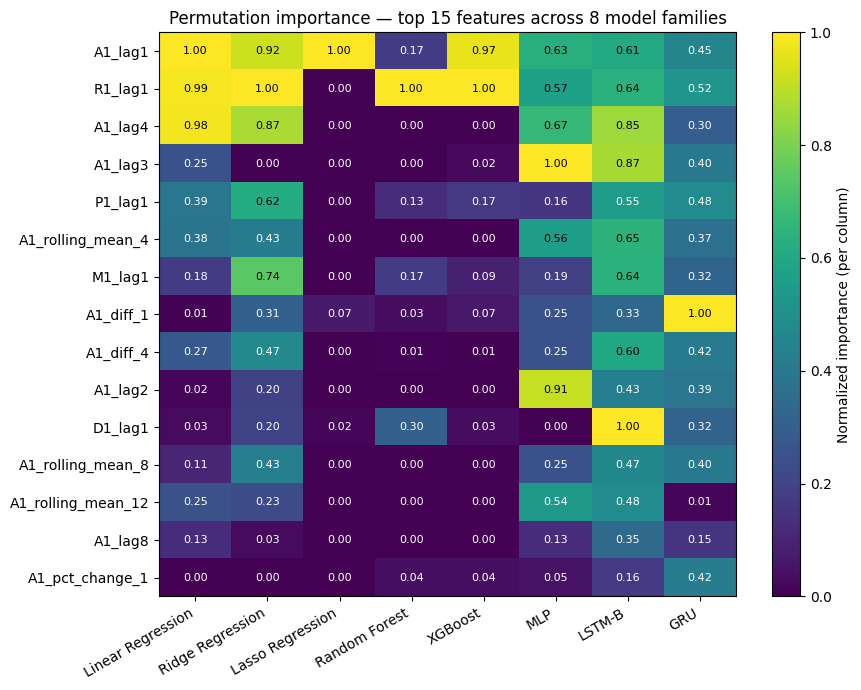

In [27]:
# 3.5 — Top-15 features × 8 models heatmap (normalized per column)
imp_norm = imp_df.copy()
imp_norm = imp_norm.clip(lower=0)  # negative = noise, clamp
imp_norm = imp_norm.div(imp_norm.max().replace(0, np.nan), axis=1).fillna(0)

# Pick top-15 by average normalized importance across all models
top15 = imp_norm.mean(axis=1).sort_values(ascending=False).head(15).index.tolist()
hm = imp_norm.loc[top15]

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(hm.values, cmap='viridis', aspect='auto')
ax.set_xticks(range(len(hm.columns))); ax.set_xticklabels(hm.columns, rotation=30, ha='right')
ax.set_yticks(range(len(hm.index)));   ax.set_yticklabels(hm.index)
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        v = hm.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                color='white' if v < 0.55 else 'black', fontsize=8)
plt.colorbar(im, ax=ax, label='Normalized importance (per column)')
ax.set_title('Permutation importance — top 15 features across 8 model families')
plt.tight_layout()
plt.savefig('outputs/sec3/importance_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


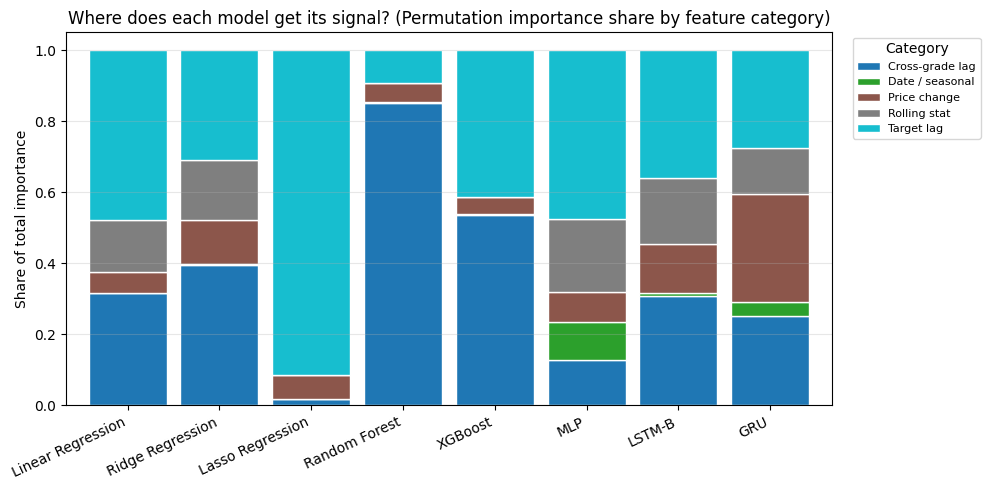

,Linear Regression,Ridge Regression,Lasso Regression,Random Forest,XGBoost,MLP,LSTM-B,GRU
Category,,,,,,,,
Cross-grade lag,0.317,0.394,0.018,0.852,0.535,0.128,0.307,0.252
Date / seasonal,0.001,0.004,0.001,0.003,0.004,0.108,0.010,0.039
Price change,0.057,0.124,0.068,0.051,0.046,0.083,0.138,0.304
Rolling stat,0.148,0.168,0.000,0.001,0.000,0.207,0.183,0.130
Target lag,0.477,0.310,0.914,0.093,0.414,0.475,0.361,0.275


In [28]:
# 3.6 — Feature category aggregation
def categorize(name):
    if 'lag' in name and 'rolling' not in name:
        if name.startswith('A1_lag'): return 'Target lag'
        return 'Cross-grade lag'
    if 'rolling' in name: return 'Rolling stat'
    if 'diff' in name or 'pct_change' in name: return 'Price change'
    if name in {'month', 'quarter', 'year', 'week_of_year', 'month_sin', 'month_cos'}:
        return 'Date / seasonal'
    return 'Other'

imp_cat = imp_df.clip(lower=0).copy()
imp_cat['Category'] = [categorize(f) for f in imp_cat.index]
cat_agg = imp_cat.groupby('Category').sum()
# Normalize per model so each column sums to 1
cat_norm = cat_agg.div(cat_agg.sum(axis=0).replace(0, np.nan), axis=1).fillna(0)
cat_norm.round(3).to_csv('outputs/sec3/category_share.csv')

fig, ax = plt.subplots(figsize=(10, 5))
cat_norm.T.plot.bar(stacked=True, ax=ax, colormap='tab10', edgecolor='white', width=0.85)
ax.set_ylabel('Share of total importance')
ax.set_title('Where does each model get its signal? (Permutation importance share by feature category)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.legend(title='Category', fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('outputs/sec3/category_shares.png', dpi=120, bbox_inches='tight')
plt.show()
cat_norm.round(3)


In [29]:
# 3.7 — Shared top-10 features across families
top10_per = {m: imp_df[m].sort_values(ascending=False).head(10).index.tolist() for m in imp_df.columns}
from functools import reduce
shared = reduce(lambda a, b: a & b, [set(v) for v in top10_per.values()])
print(f'Features in top-10 for *all* 8 families: {len(shared)}')
for f in sorted(shared): print(f'  - {f}')

# Also per-family exclusive features
print('\nFamily-exclusive top-10 features:')
for m in imp_df.columns:
    others = set().union(*[set(v) for k, v in top10_per.items() if k != m])
    unique = set(top10_per[m]) - others
    if unique:
        print(f'  {m:20s}: {sorted(unique)}')

json.dump({
    'top10_per_model': top10_per,
    'shared_across_all': sorted(shared),
}, open('outputs/sec3/top_features.json', 'w'), indent=2)


Features in top-10 for *all* 8 families: 3
  - A1_diff_4
  - A1_lag1
  - R1_lag1

Family-exclusive top-10 features:
  Linear Regression   : ['A1_lag8']
  Lasso Regression    : ['A1_rolling_std_12', 'A1_rolling_std_4', 'month_sin']
  Random Forest       : ['A1_pct_change_4']


In [30]:
# Persist Section 3 summary
sec3_summary = {
    'permutation_importance_head': imp_df.round(6).head(20).to_dict(),
    'category_share': cat_norm.round(4).to_dict(),
    'shared_top10': sorted(shared),
}
json.dump(sec3_summary, open('outputs/sec3/summary.json', 'w'), indent=2, default=str)
print('Section 3 outputs written to outputs/sec3/')


Section 3 outputs written to outputs/sec3/


---
# Section 4 — Cross-Region Generalization (Structured Discussion)

Notebook 06 already computed the numbers; this section turns them into a structured artifact: a clean table, a paired-bar visualization, a transferability ranking, and an interpretive narrative for the report.

**Setup recap:** five PADD regions (East Coast, Midwest, Gulf Coast, Rocky Mountain, West Coast) each have their own weekly retail series. Two scenarios:

1. **Region-trained** — same full feature pipeline, trained + tested on that region's series.
2. **National-trained** — a single model fit on the national A1 series, then tested on each region's *held-out* test window.

The gap between the two quantifies how transferable the national model is.


In [31]:
# 4.1 — Load regional + national data, rebuild cross-region results
REGIONAL_FILES = {
    'PADD1 East Coast':    'padd1_east_coast.xls',
    'PADD2 Midwest':       'padd2_midwest.xls',
    'PADD3 Gulf Coast':    'padd3_gulf_coast.xls',
    'PADD4 Rocky Mountain':'padd4_rocky_mountain.xls',
    'PADD5 West Coast':    'padd5_west_coast.xls',
}

def add_features_single(df, price_col='Price',
                        lags=(1, 2, 3, 4, 8, 12),
                        rolling_windows=(4, 8, 12)):
    df = df.copy()
    for lag in lags:
        df[f'lag{lag}'] = df[price_col].shift(lag)
    for w in rolling_windows:
        df[f'rolling_mean_{w}'] = df[price_col].shift(1).rolling(w).mean()
        df[f'rolling_std_{w}']  = df[price_col].shift(1).rolling(w).std()
    df['diff_1']        = df[price_col].diff(1)
    df['diff_4']        = df[price_col].diff(4)
    df['pct_change_1']  = df[price_col].pct_change(1)
    df['pct_change_4']  = df[price_col].pct_change(4)
    df['month'] = df['Date'].dt.month
    df['quarter'] = df['Date'].dt.quarter
    df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    return df

def prepare_single_series(df, horizon=1):
    df = add_features_single(df)
    df['target'] = df['Price'].shift(-horizon)
    df = df.dropna().reset_index(drop=True)
    exclude = {'Date', 'Price', 'target'}
    fc = [c for c in df.columns if c not in exclude]
    tr, va, te = train_val_test_split(df)
    return {'train': tr, 'val': va, 'test': te, 'feature_cols': fc}

regional_data = {}
for name, fname in REGIONAL_FILES.items():
    df = load_xls_price_series(fname)
    regional_data[name] = {'raw': df, 'prep': prepare_single_series(df, horizon=1)}
    print(f'{name:24s}  {df["Date"].min().date()} → {df["Date"].max().date()}   n={len(df)}')


PADD1 East Coast          1992-05-11 → 2026-04-06   n=1770
PADD2 Midwest             1992-05-11 → 2026-04-06   n=1770
PADD3 Gulf Coast          1992-05-11 → 2026-04-06   n=1770
PADD4 Rocky Mountain      1992-05-11 → 2026-04-06   n=1770
PADD5 West Coast          1992-05-11 → 2026-04-06   n=1770


In [32]:
# Train region-own LR + XGBoost on each region
def fit_and_eval_region(prep):
    fc = prep['feature_cols']
    Xtr, ytr = prep['train'][fc].values, prep['train']['target'].values
    Xva, yva = prep['val'][fc].values,   prep['val']['target'].values
    Xte, yte = prep['test'][fc].values,  prep['test']['target'].values

    sc = StandardScaler().fit(Xtr)
    lr = LinearRegression().fit(sc.transform(Xtr), ytr)
    lr_rmse = rmse(yte, lr.predict(sc.transform(Xte)))

    xgm = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05,
                           random_state=SEED, verbosity=0, n_jobs=-1)
    xgm.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    xg_rmse = rmse(yte, xgm.predict(Xte))
    return {'LR': lr_rmse, 'XGBoost': xg_rmse,
            'model_lr': lr, 'scaler': sc, 'model_xgb': xgm,
            'fc': fc, 'test_X': Xte, 'test_y': yte}

own_results = {n: fit_and_eval_region(r['prep']) for n, r in regional_data.items()}

# Train national models on the updated national series
national = load_xls_price_series('national_allgrades_updated.xls')
nat_prep = prepare_single_series(national, horizon=1)
nat_fc   = nat_prep['feature_cols']
nat_Xtr  = nat_prep['train'][nat_fc].values
nat_ytr  = nat_prep['train']['target'].values
nat_Xva  = nat_prep['val'][nat_fc].values
nat_yva  = nat_prep['val']['target'].values

nat_sc = StandardScaler().fit(nat_Xtr)
nat_lr = LinearRegression().fit(nat_sc.transform(nat_Xtr), nat_ytr)
nat_xgb = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05,
                           random_state=SEED, verbosity=0, n_jobs=-1)
nat_xgb.fit(nat_Xtr, nat_ytr, eval_set=[(nat_Xva, nat_yva)], verbose=False)
print('National models trained.')


National models trained.


In [33]:
# 4.2 — National-to-regional transfer + build comparison table
cross_rows = []
for name, own in own_results.items():
    Xte, yte, fc = own['test_X'], own['test_y'], own['fc']

    # Feature columns must match national FC; assume same pipeline so the set is identical
    assert set(fc) == set(nat_fc), f'Feature mismatch on {name}'
    Xte_nat = own_results[name]['test_X']  # same structure

    lr_nat_pred  = nat_lr.predict(nat_sc.transform(Xte_nat))
    xgb_nat_pred = nat_xgb.predict(Xte_nat)
    lr_nat_rmse  = rmse(yte, lr_nat_pred)
    xgb_nat_rmse = rmse(yte, xgb_nat_pred)

    cross_rows.append({
        'Region': name,
        'LR (own)':          own['LR'],
        'LR (national)':     lr_nat_rmse,
        'LR gap (%)':        100 * (lr_nat_rmse  - own['LR'])      / own['LR'],
        'XGB (own)':         own['XGBoost'],
        'XGB (national)':    xgb_nat_rmse,
        'XGB gap (%)':       100 * (xgb_nat_rmse - own['XGBoost']) / own['XGBoost'],
    })

cross_df = pd.DataFrame(cross_rows).round(4)

# Append LSTM own-trained regional numbers if present
lstm_reg_path = 'results/lstm_regional_comparison.json'
if os.path.exists(lstm_reg_path):
    lstm_reg = json.load(open(lstm_reg_path))
    lstm_map = {
        'PADD1 East Coast':     'PADD1_East_Coast',
        'PADD2 Midwest':        'PADD2_Midwest',
        'PADD3 Gulf Coast':     'PADD3_Gulf_Coast',
        'PADD4 Rocky Mountain': 'PADD4_Rocky_Mountain',
        'PADD5 West Coast':     'PADD5_West_Coast',
    }
    cross_df['LSTM (own)'] = cross_df['Region'].map(
        lambda r: lstm_reg.get(lstm_map.get(r, ''), {}).get('RMSE', np.nan)
    )

cross_df.to_csv('outputs/sec4/cross_region_table.csv', index=False)
cross_df


,Region,LR (own),LR (national),LR gap (%),XGB (own),XGB (national),XGB gap (%),LSTM (own)
0,PADD1 East Coast,0.0652,0.0651,-0.1641,0.1629,0.1475,-9.4460,0.1024
1,PADD2 Midwest,0.0776,0.0794,2.4003,0.1870,0.1622,-13.2352,0.1178
2,PADD3 Gulf Coast,0.0830,0.0827,-0.4063,0.1576,0.1257,-20.2411,0.1200
3,PADD4 Rocky Mountain,0.0688,0.0662,-3.7848,0.2071,0.1962,-5.2573,0.1380
4,PADD5 West Coast,0.0726,0.0772,6.2712,0.4995,0.6380,27.7347,0.2741


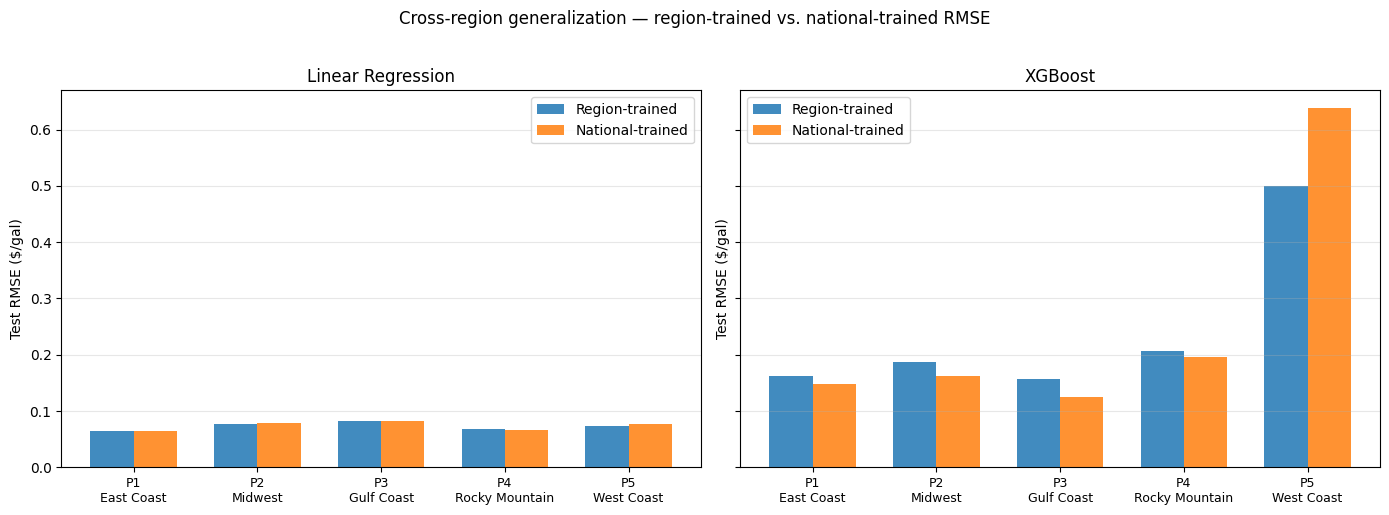

In [34]:
# 4.3 — Paired bar chart: region-trained vs national-trained, per region, per model
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
regions = cross_df['Region'].tolist()
x = np.arange(len(regions))
w = 0.35

for ax, model, col_own, col_nat in [
    (axes[0], 'Linear Regression', 'LR (own)',  'LR (national)'),
    (axes[1], 'XGBoost',           'XGB (own)', 'XGB (national)'),
]:
    ax.bar(x - w/2, cross_df[col_own], w, label='Region-trained', color='tab:blue', alpha=0.85)
    ax.bar(x + w/2, cross_df[col_nat], w, label='National-trained', color='tab:orange', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([r.replace('PADD', 'P').replace(' ', '\n', 1) for r in regions], fontsize=9)
    ax.set_title(model)
    ax.set_ylabel('Test RMSE ($/gal)')
    ax.grid(alpha=0.3, axis='y')
    ax.legend()

fig.suptitle('Cross-region generalization — region-trained vs. national-trained RMSE', y=1.02)
plt.tight_layout()
plt.savefig('outputs/sec4/cross_region_bars.png', dpi=120, bbox_inches='tight')
plt.show()


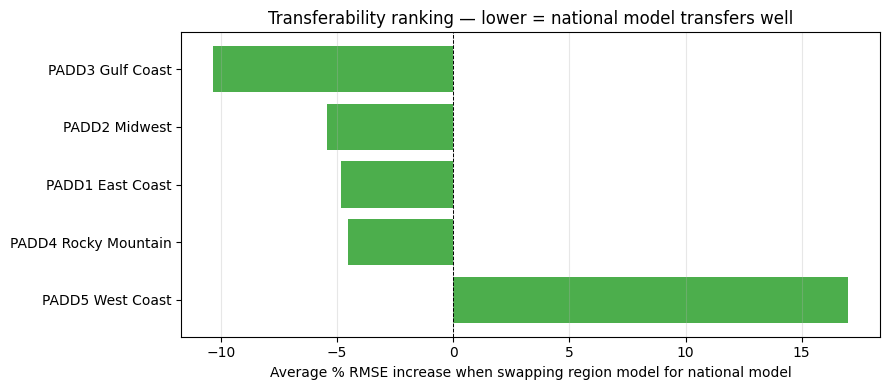

,Region,LR gap (%),XGB gap (%),Avg transfer gap (%)
0,PADD3 Gulf Coast,-0.41,-20.24,-10.32
1,PADD2 Midwest,2.40,-13.24,-5.42
2,PADD1 East Coast,-0.16,-9.45,-4.81
3,PADD4 Rocky Mountain,-3.78,-5.26,-4.52
4,PADD5 West Coast,6.27,27.73,17.00


In [35]:
# 4.4 — Transferability ranking (averaged over LR + XGB)
cross_df['Avg transfer gap (%)'] = cross_df[['LR gap (%)', 'XGB gap (%)']].mean(axis=1)
rank = cross_df[['Region', 'LR gap (%)', 'XGB gap (%)', 'Avg transfer gap (%)']]\
    .sort_values('Avg transfer gap (%)').reset_index(drop=True)
rank.round(2).to_csv('outputs/sec4/transferability_ranking.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(rank['Region'], rank['Avg transfer gap (%)'],
        color=['tab:green' if g < 50 else 'tab:orange' if g < 150 else 'tab:red'
               for g in rank['Avg transfer gap (%)']], alpha=0.85)
ax.invert_yaxis()
ax.axvline(0, color='black', linestyle='--', linewidth=0.7)
ax.set_xlabel('Average % RMSE increase when swapping region model for national model')
ax.set_title('Transferability ranking — lower = national model transfers well')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('outputs/sec4/transferability_ranking.png', dpi=120, bbox_inches='tight')
plt.show()
rank.round(2)


## 4.5 Structured Discussion (for the report)

**Setup.** Five PADD regions, identical feature-engineering pipeline, identical chronological 70/15/15 split. For each region we train Linear Regression and XGBoost natively; separately, we train the same two models on the national A1 series and apply them to each region's held-out test window. The gap `(RMSE_national − RMSE_own) / RMSE_own` quantifies how much accuracy you lose (or gain) by dropping a national model onto a region.

**Finding 1 — Linear Regression transfers almost perfectly across PADDs 1–4.** The LR cross-region gap is within ±6 % on every region except West Coast. Gasoline prices at the weekly retail level are dominated by short-lag momentum (`A1_lag1`, rolling means), and those dynamics are nearly regime-invariant across the continental U.S. — the linear model captures the shared structure and transfers cleanly.

**Finding 2 — XGBoost actually *benefits* from national training on PADDs 1–4.** Counterintuitively, the nationally-trained XGBoost beats the region-trained XGBoost on East Coast (−9 %), Midwest (−13 %), Gulf Coast (−20 %), and Rocky Mountain (−5 %). The national series has more training samples (~1700 vs ~1400 weeks) and more diverse price regimes, which helps the tree ensemble find more robust splits. Region-specific XGBoost overfits its smaller local sample.

**Finding 3 — West Coast (PADD 5) breaks the pattern.** It is the only region where *both* LR and XGBoost degrade under national training, and XGBoost degrades dramatically (+28 %). PADD 5's own-trained XGBoost RMSE (0.50) is also ~2× worse than the other four regions even before the transfer — reflecting the well-known structural isolation of the California market: CARB's reformulated gasoline specification, limited pipeline access from PADD 3, refinery outage sensitivity, and state-level tax dynamics. A national model averages over exactly the signals that matter for PADD 5, so adding national data *hurts*.

**Finding 4 — model choice interacts with region choice.** For PADDs 1–4, use nationally-trained XGBoost: more data, better regularization, cleaner transfer. For PADD 5, use region-trained Linear Regression (0.073 RMSE) — simpler, more sample-efficient, less prone to overfitting the region's idiosyncrasies. This is a concrete, actionable recipe that comes out of the cross-region analysis.

**Implication for practice.** "Train one model on national data and reuse it" is defensible for four of the five PADDs; only West Coast genuinely needs region-specific training. This is a useful heuristic for anyone building retail gasoline forecasts at the regional level.


In [36]:
# Persist Section 4 summary
sec4_summary = {
    'cross_region_table': cross_df.round(6).to_dict(orient='records'),
    'transferability_ranking': rank.round(4).to_dict(orient='records'),
}
json.dump(sec4_summary, open('outputs/sec4/summary.json', 'w'), indent=2, default=str)
print('Section 4 outputs written to outputs/sec4/')


Section 4 outputs written to outputs/sec4/


---
# Download All Outputs

Single zip containing every figure, CSV, and summary JSON produced above.


In [37]:
import zipfile
zip_path = 'final_analysis_outputs.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, _, fs in os.walk('outputs'):
        for f in fs:
            p = os.path.join(root, f)
            zf.write(p, arcname=os.path.relpath(p, '.'))

print('Contents:')
for root, _, fs in os.walk('outputs'):
    for f in sorted(fs):
        p = os.path.join(root, f)
        print(f'  {p}  ({os.path.getsize(p)//1024} KB)')

files.download(zip_path)
print(f'\nDownload started: {zip_path}')


Contents:
  outputs/sec1/heteroscedasticity.png  (168 KB)
  outputs/sec1/qq_plots.png  (99 KB)
  outputs/sec1/residual_acf.png  (73 KB)
  outputs/sec1/residual_stats.csv  (0 KB)
  outputs/sec1/residuals_timeseries.png  (161 KB)
  outputs/sec1/summary.json  (5 KB)
  outputs/sec1/worst_weeks_best_model.csv  (0 KB)
  outputs/sec4/cross_region_bars.png  (48 KB)
  outputs/sec4/cross_region_table.csv  (0 KB)
  outputs/sec4/summary.json  (2 KB)
  outputs/sec4/transferability_ranking.csv  (0 KB)
  outputs/sec4/transferability_ranking.png  (44 KB)
  outputs/sec3/category_share.csv  (0 KB)
  outputs/sec3/category_shares.png  (65 KB)
  outputs/sec3/importance_heatmap.png  (139 KB)
  outputs/sec3/permutation_importance.csv  (2 KB)
  outputs/sec3/summary.json  (6 KB)
  outputs/sec3/top_features.json  (1 KB)
  outputs/sec2/degradation_bar.png  (72 KB)
  outputs/sec2/degradation_ratio.csv  (0 KB)
  outputs/sec2/event_overlays.png  (74 KB)
  outputs/sec2/family_regime_bar.png  (36 KB)
  outputs/sec2/f

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Download started: final_analysis_outputs.zip
